# Lab 8 â€“ K-Means and Hierarchical Clustering
Implement K-Means and Hierarchical clustering algorithms to identify patterns in unlabeled data.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

In [2]:
ckd = fetch_ucirepo(id=336)

X = ckd.data.features
y = ckd.data.targets

df = pd.concat([X, y], axis=1)
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [3]:
# Replace '?' with NaN and handle missing values
df.replace('?', np.nan, inplace=True)

num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
cat_cols = [col for col in df.columns if col not in num_cols + ['class']]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Keep the true labels aside for later evaluation (not used during clustering)
true_labels = df['class'].str.strip().map({'ckd': 0, 'notckd': 1})
df_cluster = df.drop('class', axis=1)

print("Shape:", df_cluster.shape)
df_cluster.head()

Shape: (400, 24)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,3,1,0,1,1,0,0,121.0,...,15.4,44.0,7800.0,5.2,1,2,0,0,0,0
1,7.0,50.0,3,4,0,1,1,0,0,121.0,...,11.3,38.0,6000.0,4.8,0,1,0,0,0,0
2,62.0,80.0,1,2,3,1,1,0,0,423.0,...,9.6,31.0,7500.0,4.8,0,2,0,1,0,1
3,48.0,70.0,0,4,0,1,0,1,0,117.0,...,11.2,32.0,6700.0,3.9,1,1,0,1,1,1
4,51.0,80.0,1,2,0,1,1,0,0,106.0,...,11.6,35.0,7300.0,4.6,0,1,0,0,0,0


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Reduce to 2D with PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

PCA explained variance: 36.92%


---
## Part A â€“ K-Means Clustering
K-Means partitions data into K clusters by minimizing intra-cluster variance.

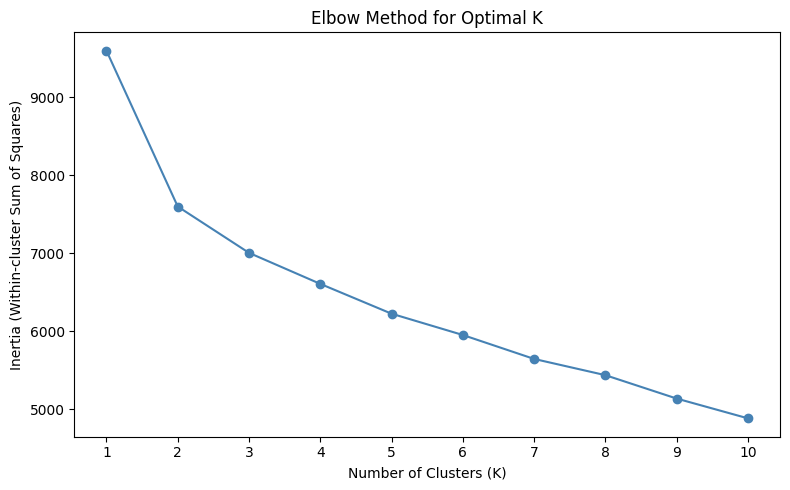

In [5]:
from sklearn.cluster import KMeans

# Elbow Method â€“ find optimal K
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

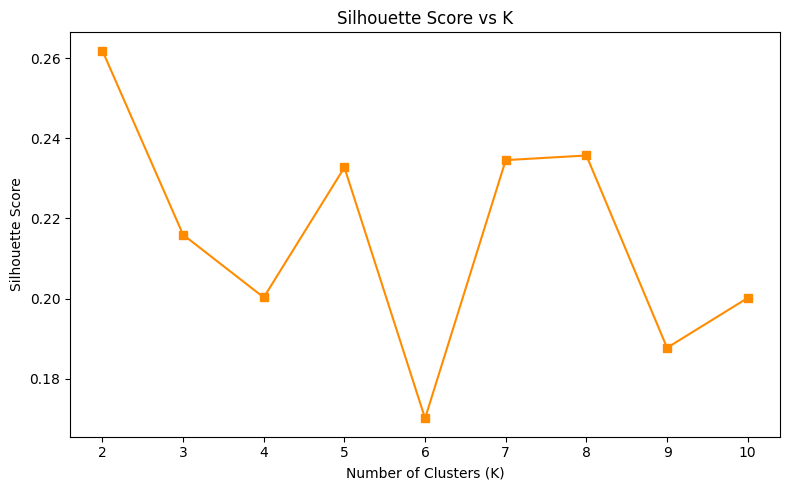

Best K by Silhouette Score = 2  (score = 0.2618)


In [6]:
from sklearn.metrics import silhouette_score

# Silhouette Scores
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='s', color='darkorange')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

best_k = np.argmax(sil_scores) + 2
print(f"Best K by Silhouette Score = {best_k}  (score = {max(sil_scores):.4f})")

K-Means (K=2) Silhouette Score: 0.2618


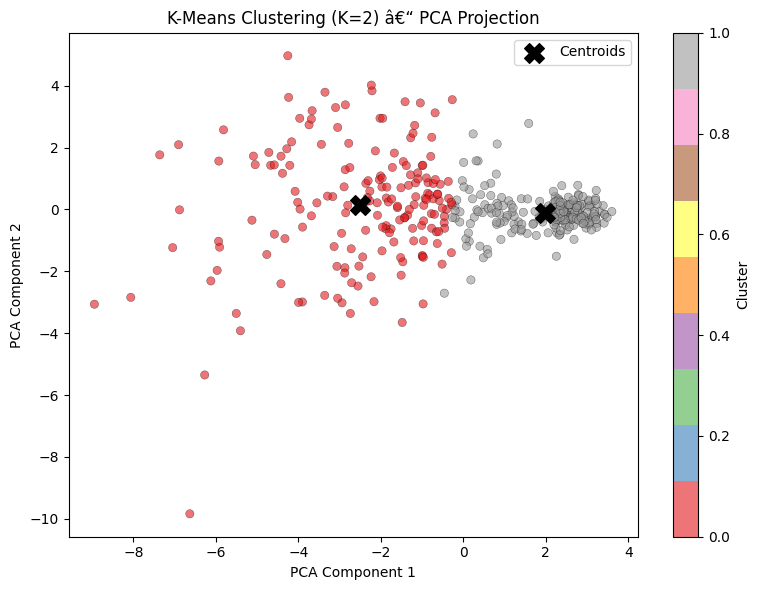

In [7]:
# Train final K-Means with K=2 (matching the binary CKD/notCKD problem)
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
km_labels = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, km_labels)
print(f"K-Means (K=2) Silhouette Score: {sil:.4f}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='Set1', alpha=0.6, edgecolors='k', linewidths=0.3)

# Plot centroids in PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering (K=2) â€“ PCA Projection')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

=== K-Means Cluster Quality (vs True Labels) ===
Adjusted Rand Index (ARI)          : 0.4013
Normalized Mutual Information (NMI): 0.4585
Silhouette Score                   : 0.2618


<Figure size 500x400 with 0 Axes>

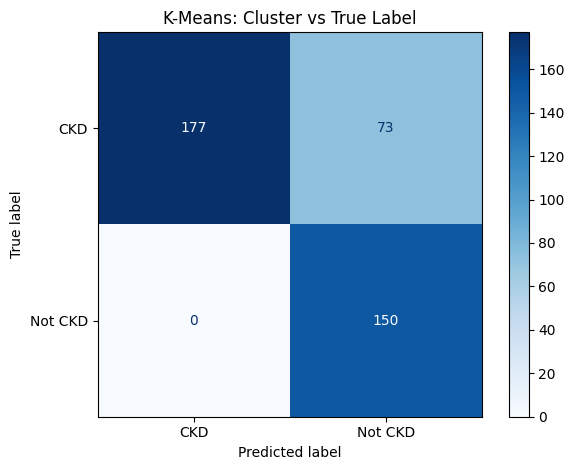

In [8]:
# Compare K-Means clusters with true CKD labels
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix, ConfusionMatrixDisplay

true = true_labels.values
ari  = adjusted_rand_score(true, km_labels)
nmi  = normalized_mutual_info_score(true, km_labels)

print("=== K-Means Cluster Quality (vs True Labels) ===")
print(f"Adjusted Rand Index (ARI)          : {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
print(f"Silhouette Score                   : {sil:.4f}")

# Align cluster labels to true labels via best mapping
from scipy.stats import mode

aligned = np.zeros_like(km_labels)
for cluster_id in range(2):
    mask = km_labels == cluster_id
    aligned[mask] = mode(true[mask], keepdims=True)[0][0]

cm_km = confusion_matrix(true, aligned)
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay(cm_km, display_labels=['CKD', 'Not CKD']).plot(cmap='Blues')
plt.title('K-Means: Cluster vs True Label')
plt.tight_layout()
plt.show()

---
## Part B â€“ Hierarchical (Agglomerative) Clustering
Hierarchical clustering builds a tree of clusters (dendrogram) without pre-specifying K.

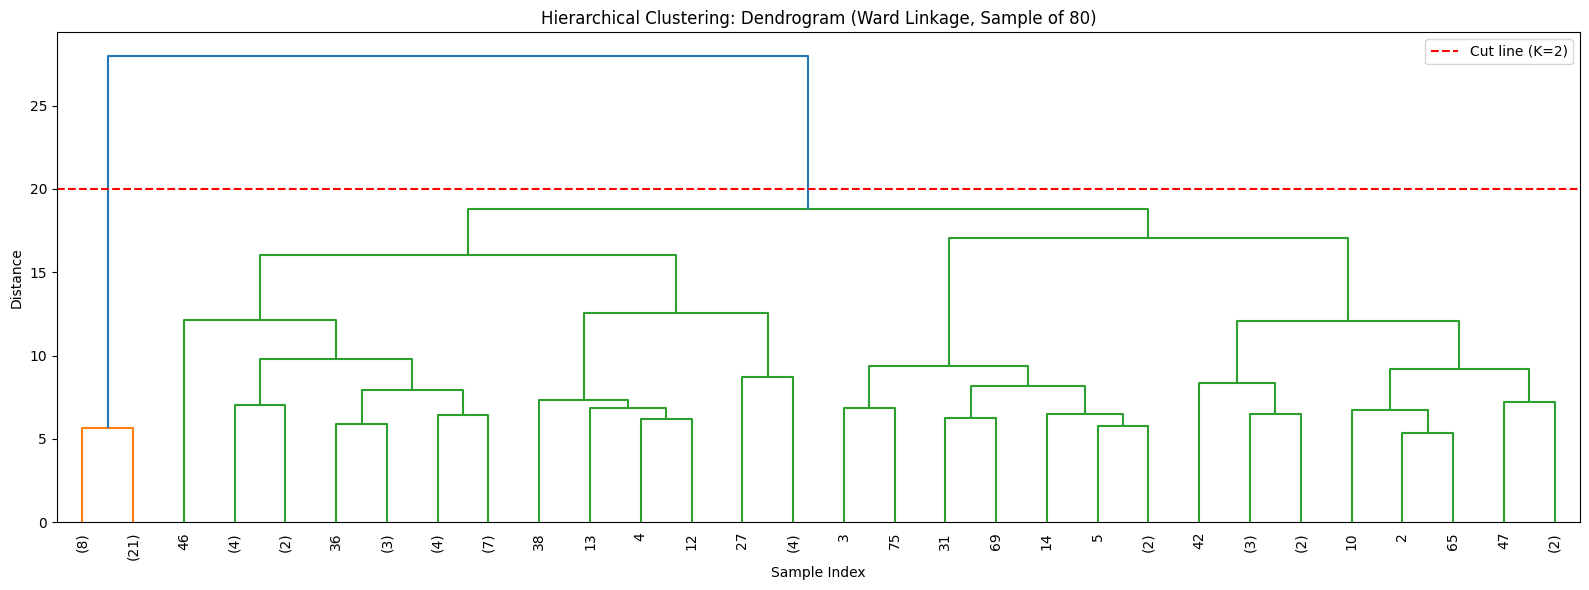

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a sample for the dendrogram (full 400 rows can be dense)
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=80, replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.axhline(y=20, color='red', linestyle='--', label='Cut line (K=2)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering: Dendrogram (Ward Linkage, Sample of 80)')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.cluster import AgglomerativeClustering

# Compare linkage methods
linkage_methods = ['ward', 'complete', 'average', 'single']
hier_results = {}

for method in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    ari = adjusted_rand_score(true, labels)
    hier_results[method] = {'labels': labels, 'silhouette': sil, 'ari': ari}
    print(f"Linkage: {method:10s} | Silhouette: {sil:.4f} | ARI: {ari:.4f}")

best_linkage = max(hier_results, key=lambda m: hier_results[m]['silhouette'])
print(f"\nBest linkage method: {best_linkage}")

Linkage: ward       | Silhouette: 0.1711 | ARI: 0.9800
Linkage: complete   | Silhouette: 0.6940 | ARI: -0.0020
Linkage: average    | Silhouette: 0.6940 | ARI: -0.0020
Linkage: single     | Silhouette: 0.6940 | ARI: -0.0020

Best linkage method: complete


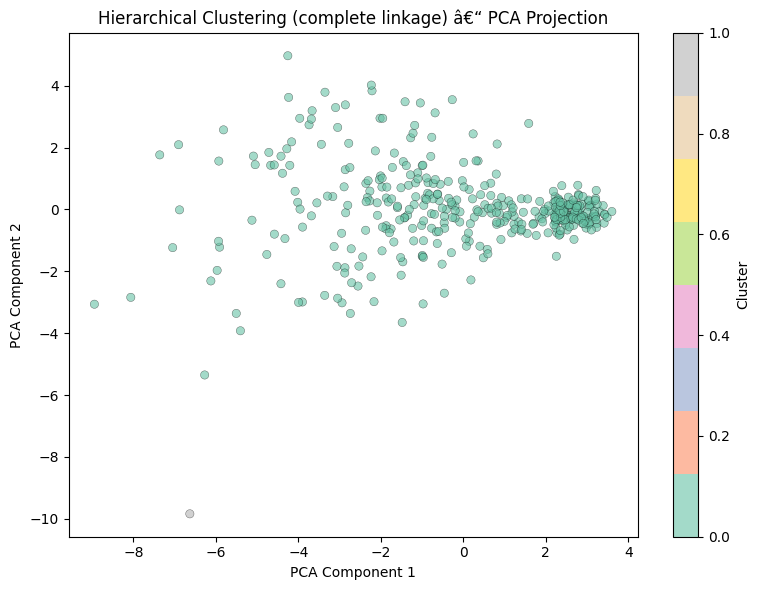

In [11]:
# Visualize best hierarchical clustering
h_labels = hier_results[best_linkage]['labels']

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=h_labels, cmap='Set2', alpha=0.6, edgecolors='k', linewidths=0.3)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'Hierarchical Clustering ({best_linkage} linkage) â€“ PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

<Figure size 500x400 with 0 Axes>

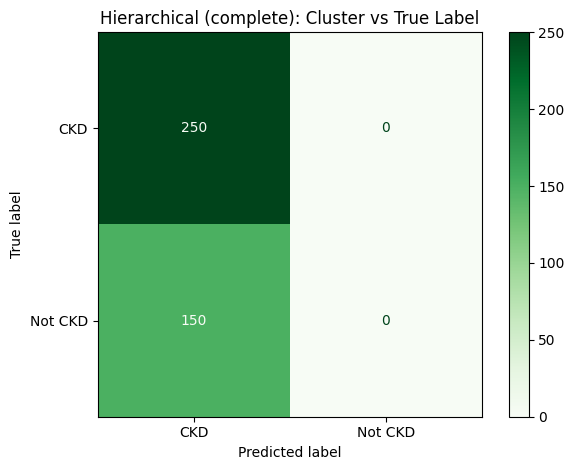

In [12]:
# Confusion matrix for best hierarchical model
aligned_h = np.zeros_like(h_labels)
for cluster_id in range(2):
    mask = h_labels == cluster_id
    aligned_h[mask] = mode(true[mask], keepdims=True)[0][0]

cm_hier = confusion_matrix(true, aligned_h)
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay(cm_hier, display_labels=['CKD', 'Not CKD']).plot(cmap='Greens')
plt.title(f'Hierarchical ({best_linkage}): Cluster vs True Label')
plt.tight_layout()
plt.show()

---
## Comparison: K-Means vs Hierarchical Clustering

                         Silhouette Score  Adjusted Rand Index       NMI
Algorithm                                                               
K-Means (K=2)                    0.261822             0.401342  0.458521
Hierarchical (complete)          0.694030            -0.001999  0.003466


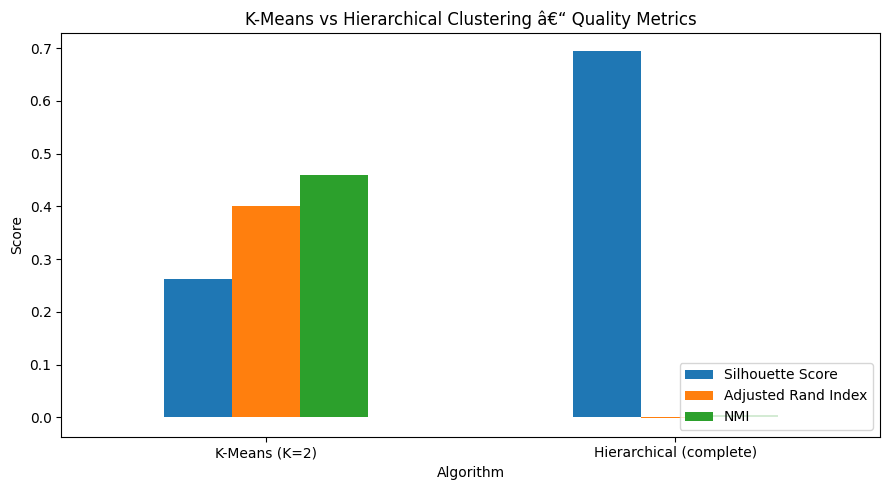

In [13]:
h_best = hier_results[best_linkage]

comparison = pd.DataFrame({
    'Algorithm': ['K-Means (K=2)', f'Hierarchical ({best_linkage})'],
    'Silhouette Score': [
        silhouette_score(X_scaled, km_labels),
        h_best['silhouette']
    ],
    'Adjusted Rand Index': [
        adjusted_rand_score(true, km_labels),
        h_best['ari']
    ],
    'NMI': [
        normalized_mutual_info_score(true, km_labels),
        normalized_mutual_info_score(true, h_best['labels'])
    ]
}).set_index('Algorithm')

print(comparison.to_string())

comparison.plot(kind='bar', figsize=(9, 5), rot=0)
plt.title('K-Means vs Hierarchical Clustering â€“ Quality Metrics')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

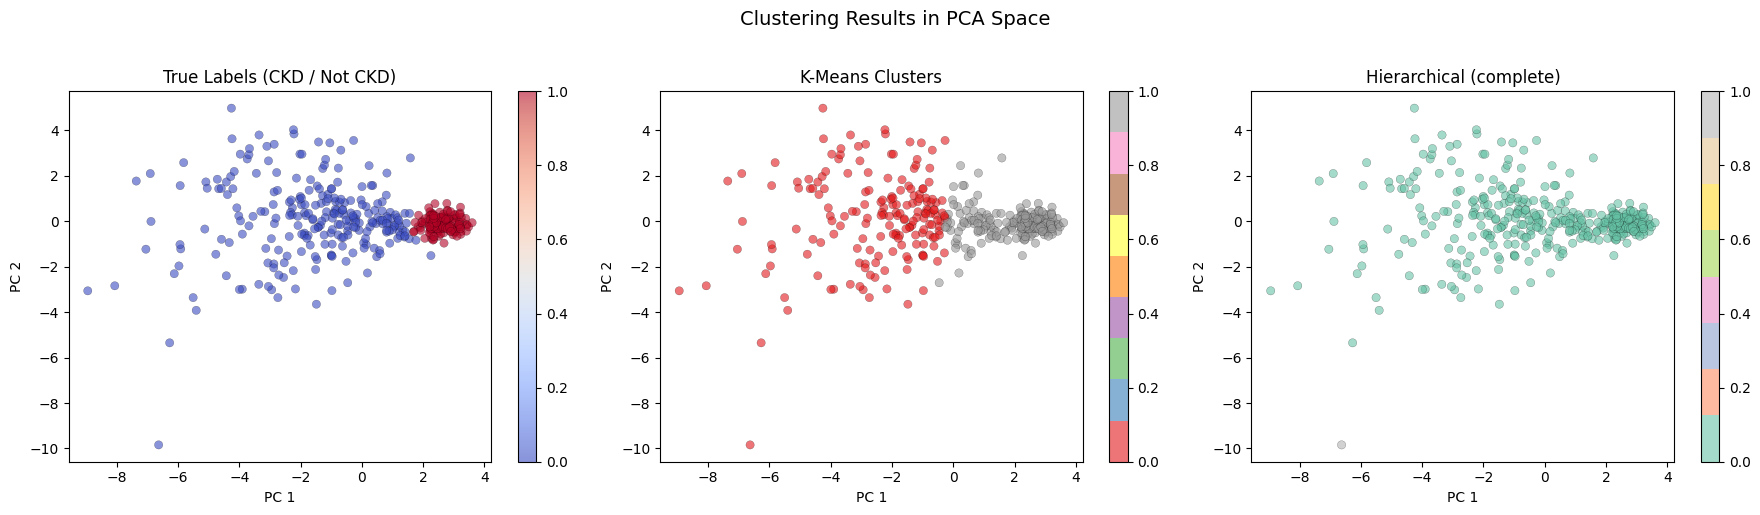

In [14]:
# Side-by-side PCA scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ['True Labels (CKD / Not CKD)', 'K-Means Clusters', f'Hierarchical ({best_linkage})']
label_sets = [true_labels.values, km_labels, h_labels]
cmaps = ['coolwarm', 'Set1', 'Set2']

for ax, title, lbl, cmap in zip(axes, titles, label_sets, cmaps):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=lbl, cmap=cmap, alpha=0.6, edgecolors='k', linewidths=0.2)
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax)

plt.suptitle('Clustering Results in PCA Space', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()